# Publication Model Fits

In [1]:
experiment_name = "gp_gaussian"
fixed_effect_name = "steps_1D"  # use None for real-data experiments
response_name = None  # only needed for real-data experiments if ambiguous
task = "in_context"  # "in_context" or "few_shot"
seed = 0
model_names = ["npboost"]
split = "TEST"
feature = None 
groups = None  # e.g. [0, 1, 2, 3]
n_groups = 4
prediction_style = "interpolated_line"  # "interval", "line", or "interpolated_line"
layout = "group_columns"  # "model_columns" or "group_columns"
line_points = 300
result_root = None  # if None, will be set automatically to default location.
show_title = False

In [2]:
from src.plot.publication_plots import (
    save_publication_model_fit_comparison,
    save_publication_model_fit_comparisons,
    save_publication_coverage_calibration,
    save_publication_fixed_effect_estimation
)


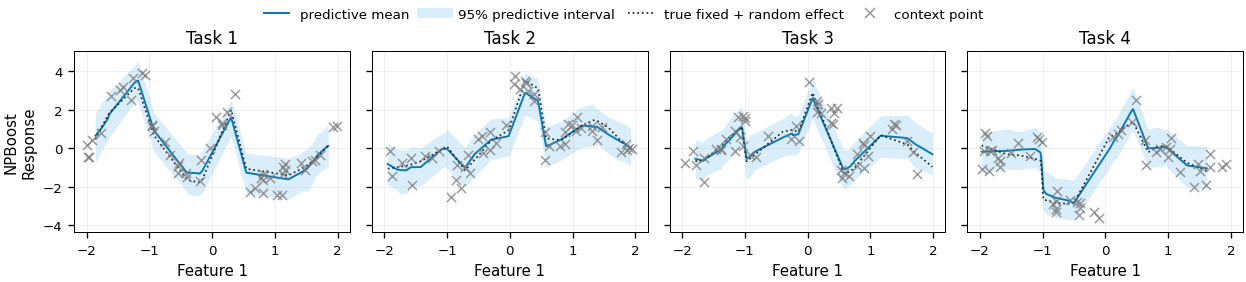

In [3]:
output_path = save_publication_model_fit_comparison(
    experiment_name=experiment_name,
    fixed_effect_name=fixed_effect_name,
    response_name=response_name,
    task=task,
    seed=seed,
    model_names=model_names,
    split=split,
    feature=feature,
    groups=groups,
    n_groups=n_groups,
    prediction_style=prediction_style,
    layout=layout,
    line_points=line_points,
    result_root=result_root,
    show_title=show_title,
    show=True,
)

In [4]:
standard_comparisons = [
    ["npboost"],
    ["npboost", "np"],
    ["npboost", "anp"],
    ["np", "anp"],
]

# Uncomment to create the full set of standard comparison PDFs.
paths = save_publication_model_fit_comparisons(
    experiment_name=experiment_name,
    fixed_effect_name=fixed_effect_name,
    response_name=response_name,
    task=task,
    seed=seed,
    comparisons=standard_comparisons,
    split=split,
    feature=feature,
    groups=groups,
    n_groups=n_groups,
    prediction_style=prediction_style,
    layout=layout,
    line_points=line_points,
    result_root=result_root,
    show_title=show_title,
)

## Few-Shot Model Fit Plots

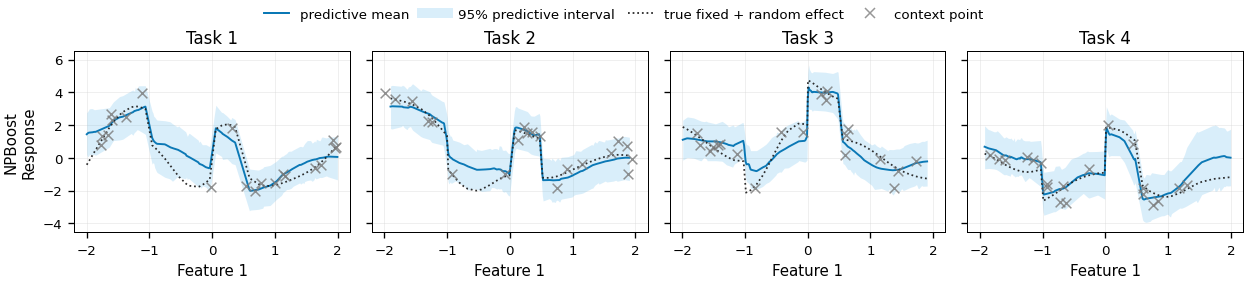

In [5]:
if "standard_comparisons" not in globals():
    standard_comparisons = [
        ["npboost"],
        ["npboost", "np"],
        ["npboost", "anp"],
        ["np", "anp"],
    ]

few_shot_fit_path = save_publication_model_fit_comparison(
    experiment_name=experiment_name,
    fixed_effect_name=fixed_effect_name,
    response_name=response_name,
    task="few_shot",
    seed=seed,
    model_names=model_names,
    split=split,
    feature=feature,
    groups=groups,
    n_groups=n_groups,
    prediction_style=prediction_style,
    layout=layout,
    line_points=line_points,
    result_root=result_root,
    show_title=show_title,
    show=True,
)

few_shot_standard_paths = save_publication_model_fit_comparisons(
    experiment_name=experiment_name,
    fixed_effect_name=fixed_effect_name,
    response_name=response_name,
    task="few_shot",
    seed=seed,
    comparisons=standard_comparisons,
    split=split,
    feature=feature,
    groups=groups,
    n_groups=n_groups,
    prediction_style=prediction_style,
    layout=layout,
    line_points=line_points,
    result_root=result_root,
    show_title=show_title,
)

## Coverage And Fixed-Effect Helpers

In [6]:
from IPython.display import display

diagnostic_tasks = ["in_context", "few_shot"]
coverage_model_names = ["np", "npboost", "anp", "anpboost"]
fixed_effect_model_names = ["npboost", "anpboost"]
nominal_levels = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95]
fixed_effect_bins = 160


## Coverage Calibration

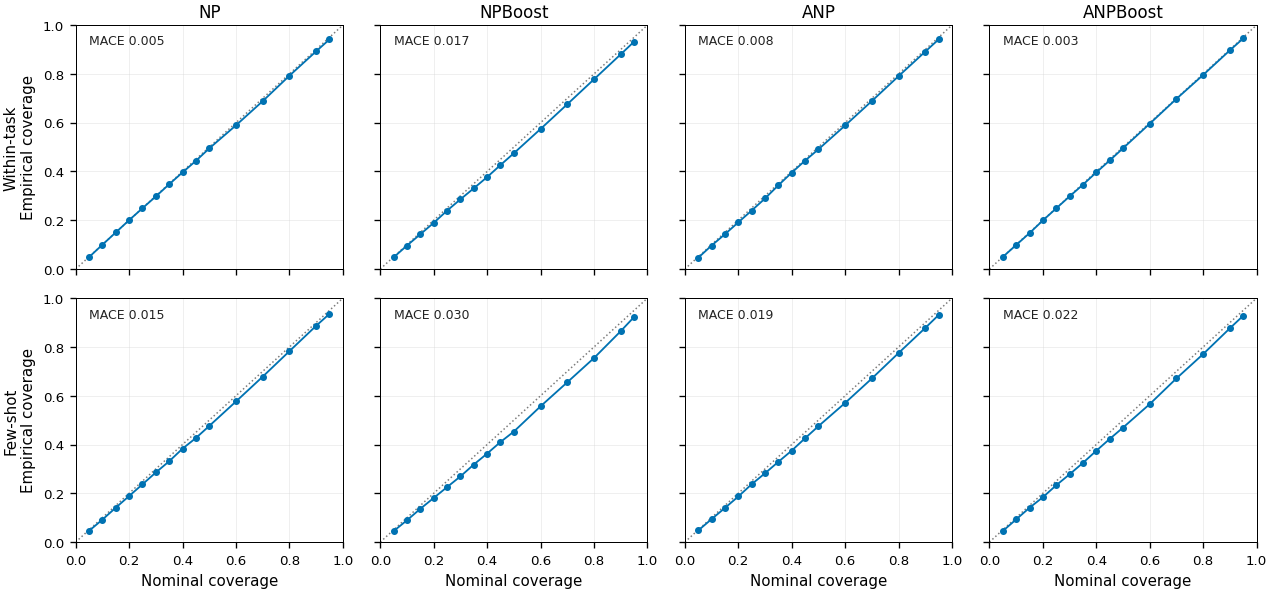

nominal_coverage          0.05   0.10   0.15   0.20   0.25   0.30   0.35  \
task_label  model_label                                                    
Few-shot    ANP          0.048  0.094  0.140  0.187  0.237  0.282  0.329   
            ANPBoost     0.045  0.093  0.141  0.184  0.233  0.278  0.325   
            NP           0.046  0.092  0.141  0.189  0.237  0.286  0.331   
            NPBoost      0.045  0.090  0.136  0.181  0.225  0.269  0.318   
Within-task ANP          0.046  0.096  0.143  0.191  0.240  0.289  0.343   
            ANPBoost     0.049  0.098  0.147  0.199  0.249  0.298  0.346   
            NP           0.049  0.100  0.150  0.200  0.249  0.298  0.348   
            NPBoost      0.048  0.096  0.143  0.189  0.239  0.286  0.331   

nominal_coverage          0.40   0.45   0.50   0.60   0.70   0.80   0.90  \
task_label  model_label                                                    
Few-shot    ANP          0.375  0.426  0.475  0.571  0.671  0.775  0.878   
            ANPBoost     0.374  0.423  0.469  0.566  0.671  0.771  0.877   
            NP           0.383  0.427  0.476  0.576  0.678  0.783  0.887   
            NPBoost      0.363  0.410  0.453  0.557  0.655  0.755  0.865   
Within-task ANP          0.395  0.444  0.491  0.589  0.689  0.791  0.892   
            ANPBoost     0.396  0.445  0.495  0.596  0.698  0.796  0.897   
            NP           0.396  0.444  0.495  0.589  0.688  0.793  0.893   
            NPBoost      0.377  0.426  0.475  0.574  0.676  0.778  0.880   

nominal_coverage          0.95  
task_label  model_label         
Few-shot    ANP          0.931  
            ANPBoost     0.928  
            NP           0.936  
            NPBoost      0.923  
Within-task ANP          0.941  
            ANPBoost     0.945  
            NP           0.942  
            NPBoost      0.932

In [7]:
coverage_plot_path, coverage_df = save_publication_coverage_calibration(
    experiment_name=experiment_name,
    fixed_effect_name=fixed_effect_name,
    response_name=response_name,
    seed=seed,
    model_names=coverage_model_names,
    task_names=diagnostic_tasks,
    split=split,
    nominal_levels=nominal_levels,
    result_root=result_root,
    show=True,
)

display(
    coverage_df.pivot_table(
        index=["task_label", "model_label"],
        columns="nominal_coverage",
        values="empirical_coverage",
    ).round(3)
)

## Fixed-Effect Estimation

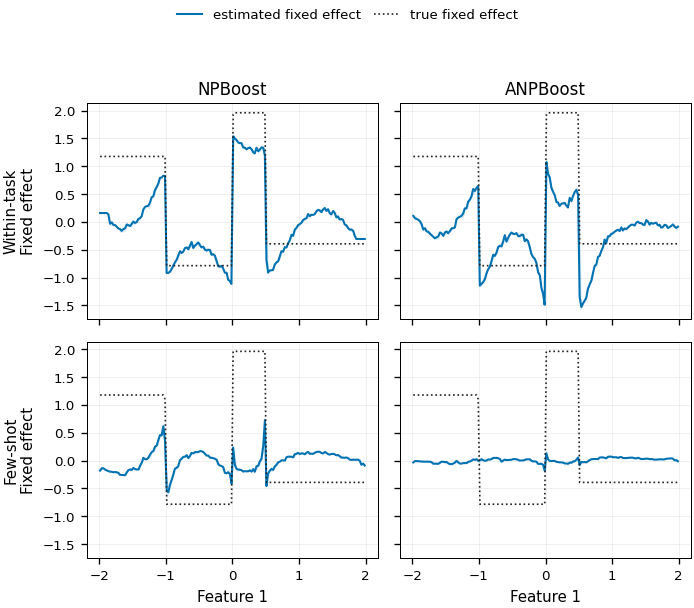

In [8]:
fixed_effect_plot_path, fixed_effect_curve_df = save_publication_fixed_effect_estimation(
    experiment_name=experiment_name,
    fixed_effect_name=fixed_effect_name,
    response_name=response_name,
    seed=seed,
    model_names=fixed_effect_model_names,
    task_names=diagnostic_tasks,
    split=split,
    feature=feature,
    n_bins=fixed_effect_bins,
    result_root=result_root,
    show=True,
)
